In [1]:
import pandas as pd

orders = pd.read_csv('olist_orders_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')

In [3]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [4]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [5]:
print("Orders missing values:")
print(orders.isnull().sum())
print("\nOrder items missing values:")
print(order_items.isnull().sum())
print("\nProducts missing values:")
print(products.isnull().sum())
print("\nCustomers missing values:")
print(customers.isnull().sum())

Orders missing values:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Order items missing values:
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

Products missing values:
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

Customers missing values:
customer_id                 0
customer_unique_id          0
customer_zi

In [6]:
print("Duplicate orders:", orders.duplicated().sum())
print("Duplicate order_items:", order_items.duplicated().sum())
print("Duplicate products:", products.duplicated().sum())
print("Duplicate customers:", customers.duplicated().sum())

Duplicate orders: 0
Duplicate order_items: 0
Duplicate products: 0
Duplicate customers: 0


In [7]:
order_reviews = pd.read_csv('olist_order_reviews_dataset.csv')
category_translation = pd.read_csv('product_category_name_translation.csv')

order_reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [8]:
category_translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [22]:
# Step 1: Join order_items with products (to identify the category of each product).
merged = order_items.merge(products, on='product_id', how='left')

# Step 2: Join with category_translation (so the category name becomes English).
merged = merged.merge(category_translation, on='product_category_name', how='left')

# Step 3: Join with order_reviews (to get the rating for each order).
merged = merged.merge(order_reviews[['order_id', 'review_score']], on='order_id', how='left')

merged.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,cool_stuff,5.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,pet_shop,4.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,furniture_decor,5.0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,perfumery,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,garden_tools,5.0


In [10]:
merged.columns.tolist()

['order_id',
 'order_item_id',
 'product_id',
 'seller_id',
 'shipping_limit_date',
 'price',
 'freight_value',
 'product_category_name',
 'product_name_lenght',
 'product_description_lenght',
 'product_photos_qty',
 'product_weight_g',
 'product_length_cm',
 'product_height_cm',
 'product_width_cm',
 'product_category_name_english',
 'review_score']

In [11]:
merged[['product_category_name_english', 'price', 'review_score']].head(10)

,product_category_name_english,price,review_score
0,cool_stuff,58.90,5.0
1,pet_shop,239.90,4.0
2,furniture_decor,199.00,5.0
3,perfumery,12.99,4.0
4,garden_tools,199.90,5.0
5,housewares,21.90,4.0
6,telephony,19.90,4.0
7,garden_tools,810.00,5.0
8,health_beauty,145.95,1.0
9,books_technical,53.99,4.0


In [12]:
category_summary = merged.groupby('product_category_name_english').agg(
    total_revenue=('price', 'sum'),
    total_sold=('order_item_id', 'count'),
    avg_review_score=('review_score', 'mean')
).reset_index()

category_summary.sort_values('total_revenue', ascending=False).head(10)

,product_category_name_english,total_revenue,total_sold,avg_review_score
43,health_beauty,1263138.54,9727,4.142768
70,watches_gifts,1206075.33,6001,4.019160
7,bed_bath_table,1050936.61,11270,3.895663
65,sports_leisure,993656.51,8700,4.107986
15,computers_accessories,919640.54,7894,3.930819
39,furniture_decor,736282.47,8415,3.903493
20,cool_stuff,637258.51,3806,4.146341
49,housewares,634542.60,6989,4.055019
5,auto,594363.10,4256,4.065512
42,garden_tools,486432.45,4361,4.042735


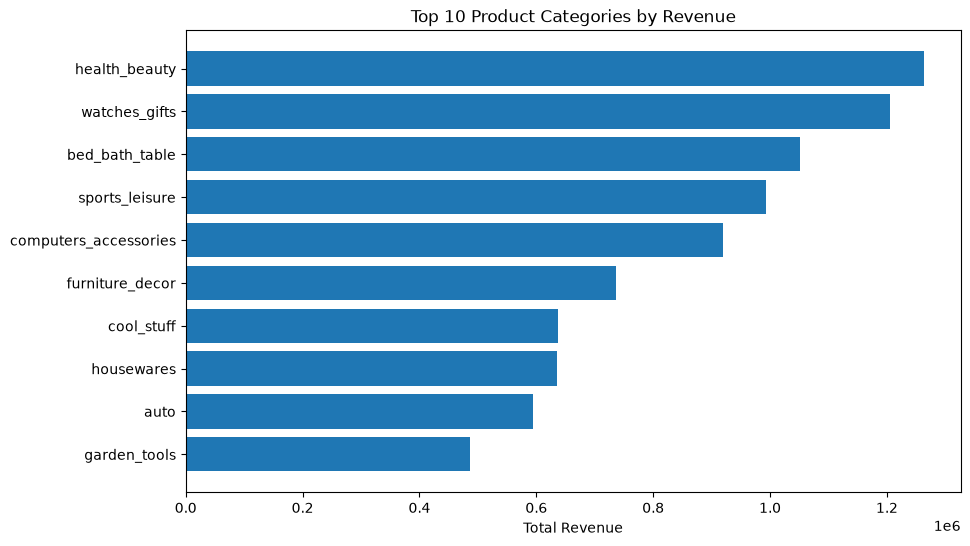

In [13]:
import matplotlib.pyplot as plt

top10 = category_summary.sort_values('total_revenue', ascending=False).head(10)
plt.figure(figsize=(10,6))
plt.barh(top10['product_category_name_english'], top10['total_revenue'])
plt.xlabel('Total Revenue')
plt.title('Top 10 Product Categories by Revenue')
plt.gca().invert_yaxis()
plt.show()

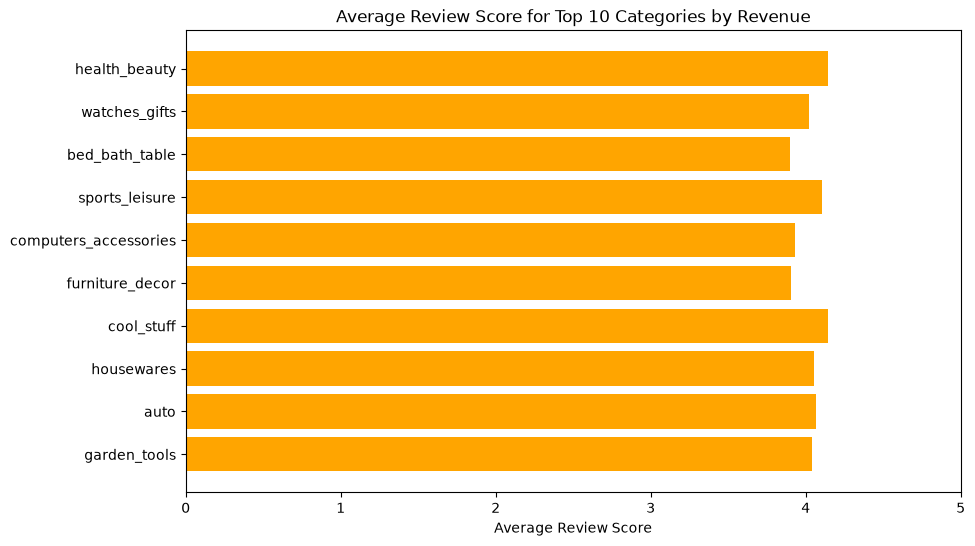

In [15]:
plt.figure(figsize=(10,6))
plt.barh(top10['product_category_name_english'], top10['avg_review_score'], color='orange')
plt.xlabel('Average Review Score')
plt.title('Average Review Score for Top 10 Categories by Revenue')
plt.gca().invert_yaxis()
plt.xlim(0, 5)
plt.show()

In [16]:
top10[['product_category_name_english', 'total_revenue', 'avg_review_score']].sort_values('avg_review_score', ascending=False)

,product_category_name_english,total_revenue,avg_review_score
20,cool_stuff,637258.51,4.146341
43,health_beauty,1263138.54,4.142768
65,sports_leisure,993656.51,4.107986
5,auto,594363.10,4.065512
49,housewares,634542.60,4.055019
42,garden_tools,486432.45,4.042735
70,watches_gifts,1206075.33,4.019160
15,computers_accessories,919640.54,3.930819
39,furniture_decor,736282.47,3.903493
7,bed_bath_table,1050936.61,3.895663


In [21]:
all_categories = merged.groupby('product_category_name_english').agg(
    total_revenue=('price', 'sum'),
    total_sold=('order_item_id', 'count'),
    avg_review_score=('review_score', 'mean')
).reset_index()

print("5 category with the highest rating:")
print(all_categories.sort_values('avg_review_score', ascending=False).head(5))

print("\n5 category with the lowest rating:")
print(all_categories.sort_values('avg_review_score', ascending=True).head(5))

5 category with the highest rating:
   product_category_name_english  total_revenue  total_sold  avg_review_score
11             cds_dvds_musicals         730.00          14          4.642857
29     fashion_childrens_clothes         569.85           8          4.500000
8         books_general_interest       46856.88         553          4.446266
22       costruction_tools_tools       15903.95         103          4.444444
35                       flowers        1110.04          33          4.419355

5 category with the lowest rating:
   product_category_name_english  total_revenue  total_sold  avg_review_score
61         security_and_services         283.29           2          2.500000
23           diapers_and_hygiene        1567.59          39          3.256410
57              office_furniture      275224.49        1701          3.493183
46                home_comfort_2         760.27          30          3.629630
30         fashion_male_clothing       10797.82         132          3

In [20]:
# Filter for categories with at least 100 sales to ensure reliable results.
reliable_categories = all_categories[all_categories['total_sold'] >= 100]

print("5 category with the highest rating (min. 100 sold):")
print(reliable_categories.sort_values('avg_review_score', ascending=False).head(5))

print("\n5 category with the lowest rating (min. 100 sold):")
print(reliable_categories.sort_values('avg_review_score', ascending=True).head(5))

5 highest category rating (min. 100 sold):
   product_category_name_english  total_revenue  total_sold  avg_review_score
8         books_general_interest       46856.88         553          4.446266
22       costruction_tools_tools       15903.95         103          4.444444
10               books_technical       19149.03         269          4.368421
37                    food_drink       15270.47         280          4.315412
53           luggage_accessories      140429.98        1092          4.315257

5 lowest category rating (min. 100 terjual):
   product_category_name_english  total_revenue  total_sold  avg_review_score
57              office_furniture      275224.49        1701          3.493183
30         fashion_male_clothing       10797.82         132          3.641221
34               fixed_telephony       59622.99         265          3.683206
4                          audio       50738.40         365          3.825485
47                  home_confort       58828.74      

In [19]:
# Merge delivery date info from the orders table
delivery_merged = merged.merge(
    orders[['order_id', 'order_delivered_customer_date', 'order_estimated_delivery_date']],
    on='order_id', how='left'
)

# Convert date columns to datetime format so we can calculate the difference
delivery_merged['order_delivered_customer_date'] = pd.to_datetime(delivery_merged['order_delivered_customer_date'])
delivery_merged['order_estimated_delivery_date'] = pd.to_datetime(delivery_merged['order_estimated_delivery_date'])

# Calculate delay in days: positive = late, negative = arrived early
delivery_merged['delivery_delay_days'] = (
    delivery_merged['order_delivered_customer_date'] - delivery_merged['order_estimated_delivery_date']
).dt.days

# Compare average delay for office_furniture vs overall average
office_delay = delivery_merged[delivery_merged['product_category_name_english'] == 'office_furniture']['delivery_delay_days'].mean()
overall_delay = delivery_merged['delivery_delay_days'].mean()

print(f"Average delay for office_furniture: {office_delay:.2f} days")
print(f"Average delay overall: {overall_delay:.2f} days")

Average delay for office_furniture: -11.81 days
Average delay overall: -12.04 days


In [23]:
# Compare average price and freight value for office_furniture vs overall
office_price = delivery_merged[delivery_merged['product_category_name_english'] == 'office_furniture']['price'].mean()
overall_price = delivery_merged['price'].mean()

office_freight = delivery_merged[delivery_merged['product_category_name_english'] == 'office_furniture']['freight_value'].mean()
overall_freight = delivery_merged['freight_value'].mean()

print(f"Average price for office_furniture: {office_price:.2f}")
print(f"Average price overall: {overall_price:.2f}")
print(f"\nAverage freight for office_furniture: {office_freight:.2f}")
print(f"Average freight overall: {overall_freight:.2f}")

# Freight as a percentage of price (higher = shipping feels more "expensive" relative to item)
office_freight_pct = (office_freight / office_price) * 100
overall_freight_pct = (overall_freight / overall_price) * 100

print(f"\nFreight as % of price (office_furniture): {office_freight_pct:.1f}%")
print(f"Freight as % of price (overall): {overall_freight_pct:.1f}%")

Average price for office_furniture: 161.80
Average price overall: 120.48

Average freight for office_furniture: 40.48
Average freight overall: 19.98

Freight as % of price (office_furniture): 25.0%
Freight as % of price (overall): 16.6%


In [25]:
# Add review comment column that we skipped earlier
delivery_merged = delivery_merged.merge(
    order_reviews[['order_id', 'review_comment_message']],
    on='order_id', how='left'
)

# Now retry filtering for office_furniture with low ratings
office_reviews = delivery_merged[
    (delivery_merged['product_category_name_english'] == 'office_furniture') &
    (delivery_merged['review_score'] <= 2) &
    (delivery_merged['review_comment_message'].notna())
]

for comment in office_reviews['review_comment_message'].head(10):
    print(comment)
    print('---')

Demora absurda para entrega, dentro do prazo especificado por eles, mas ainda sim muito demorado!
---
Comprei duas banquetas brancas no site pra ser entregue até 13/03 e até agora não recebi bem minha casa.Aguardo providências ou vou procurar meus direitos d consumidora.
---
Comprei duas banquetas brancas no site pra ser entregue até 13/03 e até agora não recebi bem minha casa.Aguardo providências ou vou procurar meus direitos d consumidora.
---
Fiz duas compras uma chegou e a outra estou com problema na entrega, não consigo contato por e-mail ou por telefone para reclamar.
---
Fiz duas compras uma chegou e a outra estou com problema na entrega, não consigo contato por e-mail ou por telefone para reclamar.
---
Fiz duas compras uma chegou e a outra estou com problema na entrega, não consigo contato por e-mail ou por telefone para reclamar.
---
Comprei a cadeira com a previsão de entrega de 2 semanas, já fazem mas de 30 dias e nada da cadeira. Comprei a mesma cadeira em outro site para u

In [26]:
# Get delay data for office_furniture only
office_delays = delivery_merged[delivery_merged['product_category_name_english'] == 'office_furniture']['delivery_delay_days']

# Check how many orders were actually late (positive delay) vs early/on-time
late_orders = (office_delays > 0).sum()
total_orders = office_delays.notna().sum()
late_percentage = (late_orders / total_orders) * 100

print(f"Total office_furniture orders with delivery data: {total_orders}")
print(f"Orders that arrived LATE: {late_orders} ({late_percentage:.1f}%)")

# Check the worst delays
print(f"\nWorst delay (max): {office_delays.max():.0f} days late")
print(f"Median delay: {office_delays.median():.0f} days")

# Distribution breakdown
print("\nDelay distribution:")
print(office_delays.describe())

Total office_furniture orders with delivery data: 1698
Orders that arrived LATE: 136 (8.0%)

Worst delay (max): 155 days late
Median delay: -13 days

Delay distribution:
count    1698.000000
mean      -11.746172
std        11.626773
min       -55.000000
25%       -17.000000
50%       -13.000000
75%        -7.000000
max       155.000000
Name: delivery_delay_days, dtype: float64


In [27]:
# Compare average rating for LATE orders vs ON-TIME/EARLY orders (office_furniture only)
office_data = delivery_merged[delivery_merged['product_category_name_english'] == 'office_furniture'].copy()

late_rating = office_data[office_data['delivery_delay_days'] > 0]['review_score'].mean()
ontime_rating = office_data[office_data['delivery_delay_days'] <= 0]['review_score'].mean()

late_count = office_data[office_data['delivery_delay_days'] > 0]['review_score'].notna().sum()
ontime_count = office_data[office_data['delivery_delay_days'] <= 0]['review_score'].notna().sum()

print(f"Average rating for LATE orders: {late_rating:.2f} (n={late_count})")
print(f"Average rating for ON-TIME/EARLY orders: {ontime_rating:.2f} (n={ontime_count})")

Average rating for LATE orders: 2.29 (n=134)
Average rating for ON-TIME/EARLY orders: 3.63 (n=1550)


In [28]:
# Add customer state info (need to go through orders table to link customer_id)
office_data = office_data.merge(
    orders[['order_id', 'customer_id']],
    on='order_id', how='left'
)
office_data = office_data.merge(
    customers[['customer_id', 'customer_state']],
    on='customer_id', how='left'
)

# Check delay and rating by state, only for states with enough orders
state_summary = office_data.groupby('customer_state').agg(
    total_orders=('order_id', 'count'),
    avg_delay=('delivery_delay_days', 'mean'),
    avg_rating=('review_score', 'mean'),
    late_pct=('delivery_delay_days', lambda x: (x > 0).mean() * 100)
).reset_index()

# Only show states with at least 20 orders for reliability
reliable_states = state_summary[state_summary['total_orders'] >= 20].sort_values('late_pct', ascending=False)
print(reliable_states)

   customer_state  total_orders  avg_delay  avg_rating   late_pct
7              MA            23  -9.000000    3.363636  30.434783
13             PE            20 -11.600000    3.400000  15.000000
3              CE            28 -13.392857    3.142857  14.285714
16             RJ           309 -11.661184    3.142395  11.326861
2              BA            95 -12.284211    3.663158  10.526316
10             MT            20 -12.750000    3.263158  10.000000
20             RS            71 -12.173913    3.802817   8.450704
21             SC            62 -11.133333    3.387097   8.064516
15             PR            95 -13.604396    3.494737   7.368421
5              ES            30 -13.066667    3.666667   6.666667
23             SP           680 -10.627043    3.616071   6.176471
8              MG           167 -14.688623    3.524390   1.796407
6              GO            22 -15.363636    4.227273   0.000000
11             PA            27 -18.153846    2.814815   0.000000


In [29]:
# Look at review comments specifically from PA state
pa_reviews = office_data[
    (office_data['customer_state'] == 'PA') &
    (office_data['review_comment_message'].notna())
]

for comment in pa_reviews['review_comment_message'].head(10):
    print(comment)
    print('---')

Comprei duas cadeiras, uma o assento ñ encaixa corretamente e a outra veio sem as borrachinhas para acabamento
---
Comprei duas cadeiras, uma o assento ñ encaixa corretamente e a outra veio sem as borrachinhas para acabamento
---
Comprei e paguei por uma cadeira giratória com braço e recebi uma cadeira sem braço! Quero devolver o produto, não supre a minha necessidade 
---
Boa noite!
Estou muito indignada pois comprei 2 cadeiras secretaria e só recebi até hj apenas uma!
Sendo que na nota consta 2 unidades!
Solicito providências urgentes !!!
---
Boa noite!
Estou muito indignada pois comprei 2 cadeiras secretaria e só recebi até hj apenas uma!
Sendo que na nota consta 2 unidades!
Solicito providências urgentes !!!
---
Chegou muito antes do previsto,recomendo super
---
Cadeira conforme descrita no site. Tudo certo.
---
Não fiquei totalmente satisfeita porque esse produto não foi entregue na minha residência, pois tive que me dirigir até o correio para retirar a mercadoria. 
---
Comprei 2 